# Assignment 5

Deadline: xx.xx.2026 12:00 CEST

## Task

Develop an investment strategy for the Swiss equity market, backtest it using the provided datasets (i.e., `market_data.parquet`, `jkp_data.parquet`, `spi_index.csv`) and analyze its performance by benchmarking it against the Swiss Performance Index (SPI). Build on the existing qpmwp-course codebase and extend it with any additional components required. Summarize your approach and findings in a written report.

### Coding (15 points)



- Selection:
  Use some of the existing selection item builder functions (in `bibfn_selection.py`, applied via `SelectionItemBuilder`) to filter stocks based on specific criteria, and/or implement your own filters (e.g., exclude low-quality or high-volatility stocks).

- Optimization Data & Constraints:
  Use the implemented functions for preparing optimization inputs (in `bibfn_optimization_data.py`, applied via `OptimizationItemBuilder`) and for specifying constraints such as stock, sector, or factor exposure limits (in `bibfn_constraints.py`, applied via `OptimizationItemBuilder`). Extend these with your own functions where appropriate.

- Signal Generation:
  Use a machine learning method to estimate optimization inputs such as expected returns or risk. Possible approaches include regression, classification, or learning-to-rank models. A good starting point is the demo notebook `xsection_regressor.ipynb` which shows how to generate predictive signals. Use jkp_data as features or engineer your own (e.g., technical indicators from returns or prices). Alternatively, or in combination, you may use a factor model to construct the optimization inputs.

- Optimization Model:
  Use an optimization model to determine portfolio weights. You may rely on an existing class (e.g., `MeanVariance`, `LeastSquares`, or `BlackLitterman`) or implement a custom model. If you choose to create a custom optimization model, develop a class inheriting from `Optimization` and ensure implement the methods `set_objective` (to construct the coefficients of the objective function) and `solve` (to run the optimization).

- Simulation:
  Backtest the strategy and simulate portfolio returns, incorporating fixed costs of 1% per year and transaction costs of 0.2% per rebalancing.


### Report (15 points):

Produce an HTML report (for example, by converting a .ipynb notebook to HTML) containing:

- High-level strategy overview: A clear description of the investment strategy and its rationale.

- Detailed explanation of the backtesting steps: A step-by-step explanation of the backtest design, including model choices and implementation details (e.g., the machine learning method or factor model used).

- Backtesting results:
    
    - Charts: Visualizations such as cumulative performance, rolling 3-year returns, etc.
    - Descriptive statistics: Key statistics such as mean, standard deviation, drawdown, turnover, and Sharpe ratio (or any other relevant metric) for the full backtest period as well as for subperiods (e.g., the last 5 years, or during bull vs. bear market phases).
    - Compare your strategy against the SPI.


## Strategy overview

The strategy is an active Swiss equity strategy. It uses a rolling cross-sectional Ridge regression to predict next-quarter relative stock returns from JKP characteristics and technical indicators. The predicted signal is converted into a cross-sectional rank and used directly in a constrained score-risk optimization. The optimizer is long-only, fully invested, liquidity-filtered, capped at 5% per stock, and penalizes covariance risk. The strategy is simulated gross and net of 1% annual fixed costs and 0.2% transaction costs per unit of turnover.

## Imports and paths

In [17]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

project_root = Path.cwd()
while not (project_root / 'src').exists() and project_root != project_root.parent:
    project_root = project_root.parent

src_path = project_root / 'src'
sys.path.append(str(project_root))
sys.path.append(str(src_path))

from helper_functions import load_data_spi, align_market_data_with_jkp_data
from estimation.covariance import Covariance
from optimization.optimization import ScoreVariance
from backtesting.backtest_item_builder.bib_classes import SelectionItemBuilder, OptimizationItemBuilder
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_min_volume,
    bibfn_selection_jkp_data_scores,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
    bibfn_scores,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

PATH_TO_DATA = project_root / 'data'
SAVE_PATH = project_root / 'output'
SAVE_PATH.mkdir(exist_ok=True)

np.random.seed(42)

## Load data

In [18]:
market_data = pd.read_parquet(PATH_TO_DATA / 'market_data.parquet')
jkp_data = pd.read_parquet(PATH_TO_DATA / 'jkp_data.parquet')
spi = load_data_spi(path=str(PATH_TO_DATA))

market_data_ffill, jkp_data = align_market_data_with_jkp_data(
    market_data=market_data,
    jkp_data=jkp_data,
)

data = BacktestData()
data.market_data = market_data_ffill
data.jkp_data = jkp_data
data.bm_series = spi

market_data.shape, jkp_data.shape, spi.shape

((1434082, 4), (83421, 153), (9251,))

## Rebalancing dates

In [19]:
n_month = 3
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique()
    .sort_values()
)

rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data.index.get_level_values('date').min()
    ][::n_month]
    .strftime('%Y-%m-%d')
    .tolist()
)

rebdates = [date for date in rebdates if date > '2002-01-01' and date < rebdates[-1]]
rebdates[:5], rebdates[-5:], len(rebdates)

(['2002-01-31', '2002-04-30', '2002-07-31', '2002-10-31', '2003-01-31'],
 ['2022-10-31', '2023-01-31', '2023-04-30', '2023-07-31', '2023-10-31'],
 88)

## Machine-learning signal

The model is trained only on past observations. At each rebalancing date, the previous 20 quarterly observations are used to estimate a Ridge regression. The target is the next-quarter cross-sectional return rank. The prediction is transformed into a cross-sectional rank and stored as `ml_signal`.

In [20]:
FEATURE_COLS = [
    'ret_6_1',
    'ret_12_1',
    'ret_9_1',
    'prc_highprc_252d',
    'resff3_6_1',
    'resff3_12_1',
    'be_me',
    'at_me',
    'fcf_me',
    'ocf_me',
    'sale_me',
    'ebitda_mev',
    'gp_at',
    'op_at',
    'cop_at',
    'qmj',
    'qmj_prof',
    'qmj_growth',
    'qmj_safety',
    'at_gr1',
    'inv_gr1a',
    'oaccruals_at',
    'taccruals_at',
    'debt_me',
    'netdebt_me',
    'beta_60m',
    'betabab_1260d',
    'ivol_ff3_21d',
    'ivol_capm_252d',
    'rvol_21d',
    'rmax1_21d',
    'turnover_126d',
    'dolvol_126d',
]

feature_cols = [col for col in FEATURE_COLS if col in jkp_data.columns]
feature_cols

['ret_6_1',
 'ret_12_1',
 'ret_9_1',
 'prc_highprc_252d',
 'resff3_6_1',
 'resff3_12_1',
 'be_me',
 'at_me',
 'fcf_me',
 'ocf_me',
 'sale_me',
 'ebitda_mev',
 'gp_at',
 'op_at',
 'cop_at',
 'qmj',
 'qmj_prof',
 'qmj_growth',
 'qmj_safety',
 'at_gr1',
 'inv_gr1a',
 'oaccruals_at',
 'taccruals_at',
 'debt_me',
 'netdebt_me',
 'beta_60m',
 'betabab_1260d',
 'ivol_ff3_21d',
 'ivol_capm_252d',
 'rvol_21d',
 'rmax1_21d',
 'turnover_126d',
 'dolvol_126d']

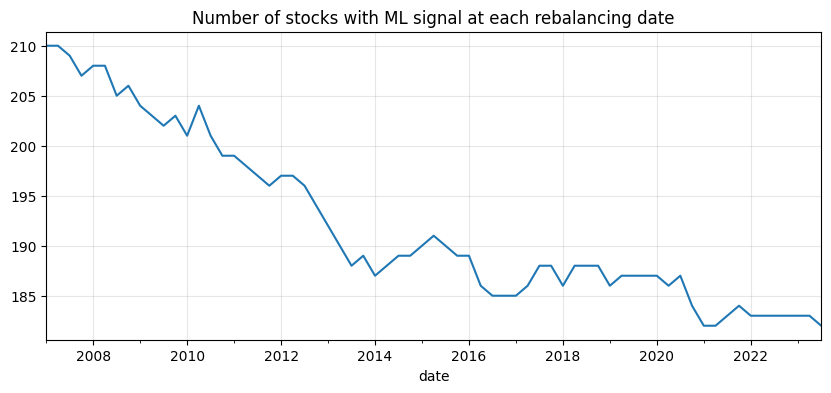

id,1,10,100,101,102,103,104,105,108,111,...,84,85,86,87,88,89,91,93,94,95
date,,,,,,,,,,,,,,,,,,,,,
2007-01-31,0.209524,0.704762,0.971429,0.919048,0.761905,0.700000,0.166667,0.995238,0.976190,0.419048,...,0.561905,0.204762,0.314286,0.604762,NaN,0.928571,0.823810,0.914286,0.876190,0.680952
2007-04-30,0.300000,0.876190,1.000000,0.800000,0.890476,0.885714,0.347619,0.995238,0.985714,0.366667,...,0.900000,0.123810,0.309524,0.871429,NaN,0.957143,0.400000,0.719048,0.700000,0.814286
2007-07-31,0.478469,0.741627,1.000000,0.569378,0.870813,0.765550,0.650718,0.995215,0.779904,0.521531,...,0.846890,0.114833,0.526316,0.430622,NaN,0.894737,0.272727,0.885167,0.622010,0.287081
2007-10-31,0.338164,NaN,1.000000,0.748792,0.777778,0.405797,0.719807,0.975845,0.855072,0.937198,...,0.676329,0.202899,0.492754,0.652174,NaN,0.768116,0.632850,0.908213,0.700483,0.314010
2008-01-31,0.403846,NaN,0.932692,0.836538,0.802885,0.485577,0.769231,0.899038,0.995192,0.927885,...,0.572115,0.100962,0.451923,0.788462,NaN,0.875000,0.658654,0.865385,0.783654,0.384615


In [21]:
prices = market_data_ffill.pivot_table(
    index='date',
    columns='id',
    values='price',
).sort_index()

grid_dates = pd.to_datetime(rebdates)
grid_prices = prices.reindex(grid_dates, method='ffill')
forward_returns = grid_prices.pct_change(fill_method=None).shift(-1)

def get_features_at_date(date):
    date = pd.to_datetime(date)
    df = jkp_data[feature_cols]
    df = df.loc[
        (df.index.get_level_values('date') <= date) &
        (df.index.get_level_values('date') >= date - pd.Timedelta(days=365))
    ]
    df = df.groupby('id').last()
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.rank(axis=0, pct=True)
    return df

X_by_date = {date: get_features_at_date(date) for date in grid_dates}

train_window = 20
predictions = {}

model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=10.0)),
])

for i in range(train_window, len(grid_dates) - 1):
    pred_date = grid_dates[i]
    train_dates = grid_dates[i - train_window:i]

    X_train_list = []
    y_train_list = []

    for train_date in train_dates:
        X_tmp = X_by_date[train_date]
        y_tmp = forward_returns.loc[train_date].dropna()
        common_ids = X_tmp.index.intersection(y_tmp.index)

        X_train_list.append(X_tmp.loc[common_ids])
        y_train_list.append(y_tmp.loc[common_ids].rank(pct=True))

    X_train = pd.concat(X_train_list, axis=0)
    y_train = pd.concat(y_train_list, axis=0)

    train_data = X_train.copy()
    train_data['target'] = y_train.values
    train_data = train_data.dropna(subset=['target'])

    X_pred = X_by_date[pred_date]
    X_pred = X_pred.dropna(how='all')

    model.fit(train_data[feature_cols], train_data['target'])
    predictions[pred_date] = pd.Series(
        model.predict(X_pred[feature_cols]),
        index=X_pred.index,
        name=pred_date,
    )

ml_signal_raw = pd.DataFrame(predictions).T
ml_signal_raw.index.name = 'date'
ml_signal_raw.columns.name = 'id'

ml_signal = ml_signal_raw.rank(axis=1, pct=True)
ml_signal.index.name = 'date'
ml_signal.columns.name = 'id'

ml_signal_path = SAVE_PATH / 'assignment_5_ml_signal.parquet'
ml_signal.to_parquet(ml_signal_path)

ml_signal_stack = ml_signal.stack().rename('ml_signal').astype('float64')
ml_signal_stack.index.names = jkp_data.index.names

jkp_data = jkp_data.join(ml_signal_stack, how='left')
data.jkp_data = jkp_data

ml_signal.count(axis=1).plot(
    title='Number of stocks with ML signal at each rebalancing date',
    figsize=(10, 4),
)
plt.grid(alpha=0.3)
plt.show()

ml_signal.head()

## ML signal diagnostics

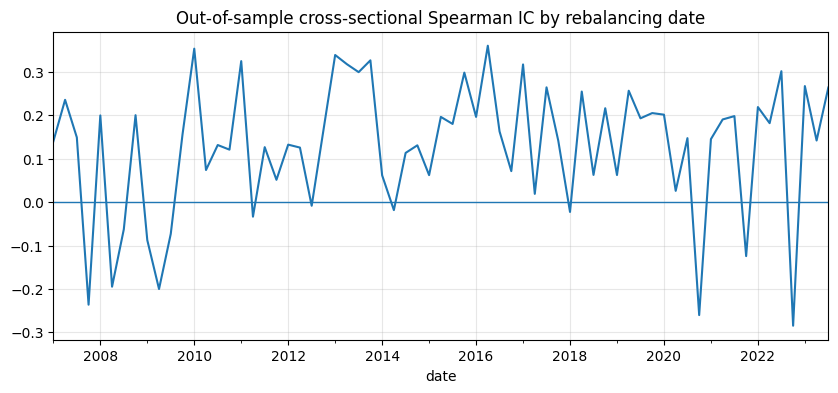

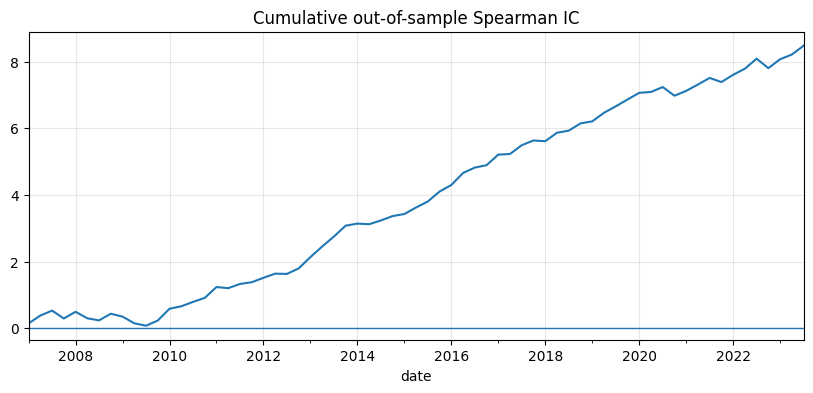

,Mean IC,Median IC,IC Volatility,Positive IC Share
0,0.126601,0.147495,0.153453,0.80597


In [22]:
realized_forward_ranks = forward_returns.loc[ml_signal.index].rank(axis=1, pct=True)
signal_ic = ml_signal.corrwith(realized_forward_ranks, axis=1, method='spearman').dropna()

signal_ic.plot(
    title='Out-of-sample cross-sectional Spearman IC by rebalancing date',
    figsize=(10, 4),
)
plt.axhline(0, linewidth=1)
plt.grid(alpha=0.3)
plt.show()

signal_ic.cumsum().plot(
    title='Cumulative out-of-sample Spearman IC',
    figsize=(10, 4),
)
plt.axhline(0, linewidth=1)
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({
    'Mean IC': [signal_ic.mean()],
    'Median IC': [signal_ic.median()],
    'IC Volatility': [signal_ic.std()],
    'Positive IC Share': [(signal_ic > 0).mean()],
})

## Custom quality-risk selection filter

The custom filter removes stocks with weak quality and extreme realized/idiosyncratic risk. This is applied in addition to the course-provided liquidity and data-availability filters.

In [23]:
def bibfn_selection_quality_risk(bs, rebdate: str, **kwargs) -> pd.DataFrame:
    min_quality_pct = kwargs.get('min_quality_pct', 0.20)
    max_risk_pct = kwargs.get('max_risk_pct', 0.85)

    quality_fields = [field for field in ['qmj', 'qmj_safety'] if field in bs.data.jkp_data.columns]
    risk_fields = [field for field in ['ivol_ff3_21d', 'rvol_21d'] if field in bs.data.jkp_data.columns]
    fields = quality_fields + risk_fields

    df = bs.data.jkp_data[fields]
    df = df.loc[
        (df.index.get_level_values('date') <= rebdate) &
        (df.index.get_level_values('date') >= pd.to_datetime(rebdate) - pd.Timedelta(days=365))
    ]
    df = df.groupby('id').last()

    quality_score = df[quality_fields].rank(pct=True).mean(axis=1)
    risk_score = df[risk_fields].rank(pct=True).mean(axis=1)

    binary = (
        (quality_score >= min_quality_pct) &
        (risk_score <= max_risk_pct)
    ).astype(int)

    return pd.DataFrame({
        'values': quality_score - risk_score,
        'binary': binary,
    }, index=df.index)

## Backtest setup

The optimizer maximizes the ML score while penalizing covariance risk. It uses 3 years of daily return history for covariance estimation, a full-investment budget constraint, and long-only box constraints with a 5% maximum individual stock weight.

In [24]:
JKP_FIELDS_ML = ['ml_signal']
active_rebdates = [date for date in rebdates if pd.to_datetime(date) in ml_signal.index]

selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365,
        min_volume=500_000,
        agg_fn=np.median,
    ),
    'quality_risk': SelectionItemBuilder(
        bibfn=bibfn_selection_quality_risk,
        min_quality_pct=0.20,
        max_risk_pct=0.85,
    ),
    'jkp_data_scores': SelectionItemBuilder(
        bibfn=bibfn_selection_jkp_data_scores,
        fields=JKP_FIELDS_ML,
    ),
}

optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fillna_value=0,
    ),
    'scores': OptimizationItemBuilder(
        bibfn=bibfn_scores,
        fields=JKP_FIELDS_ML,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1,
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        lower=0,
        upper=0.05,
        box_type='LongOnly',
    ),
}

optimization = ScoreVariance(
    field='ml_signal',
    covariance=Covariance(method='pearson', check_positive_definite=True),
    risk_aversion=250,
    solver_name='cvxopt',
)

bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    optimization=optimization,
    rebdates=active_rebdates,
    quiet=True,
)

active_rebdates[:5], active_rebdates[-5:], len(active_rebdates)

(['2007-01-31', '2007-04-30', '2007-07-31', '2007-10-31', '2008-01-31'],
 ['2022-07-31', '2022-10-31', '2023-01-31', '2023-04-30', '2023-07-31'],
 67)

## Run backtest

In [25]:
bt_ml_sv = Backtest()
bt_ml_sv.run(bs=bs)

bt_ml_sv.save(
    path=str(SAVE_PATH),
    filename='assignment_5_ml_score_variance.pickle',
)

len(bt_ml_sv.strategy.portfolios)

Backtest object saved successfully to c:\Users\Uporabnik\Desktop\qpmwp-course\output\assignment_5_ml_score_variance.pickle


67

## Portfolio weights and turnover

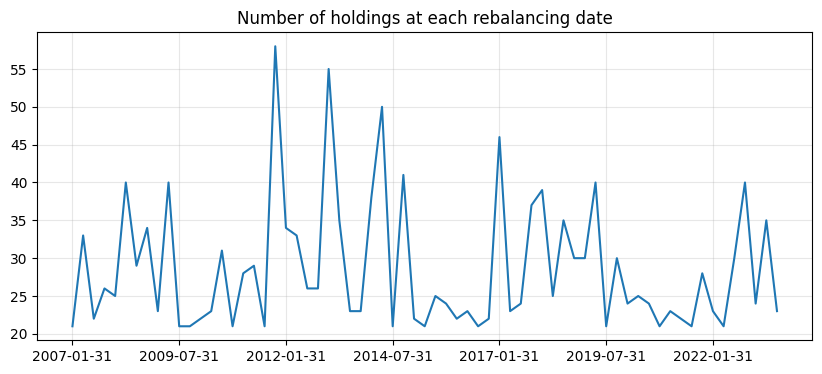

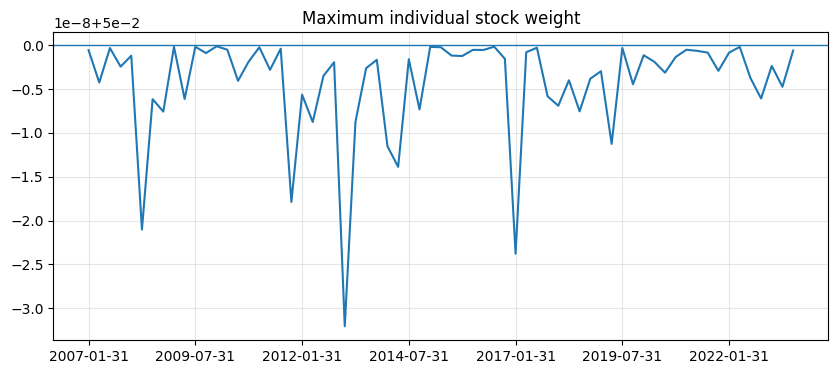

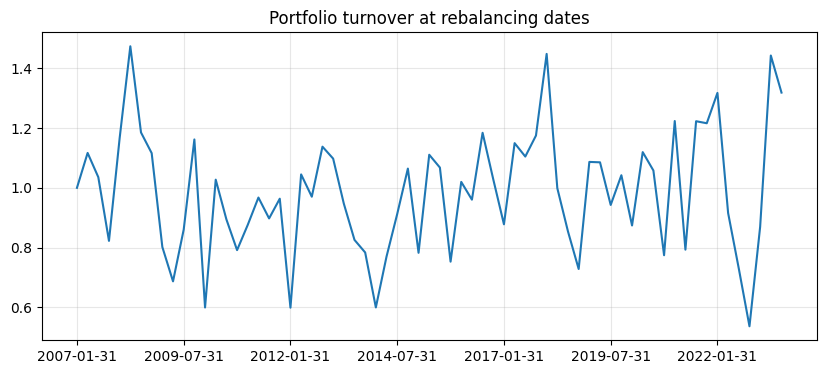

,Mean Positions,Mean Max Weight,Mean Turnover,Median Turnover,Max Turnover
0,28.61194,0.05,0.98523,0.998718,1.473151


In [26]:
return_series = data.get_return_series(weekdays_only=False)
weights = bt_ml_sv.strategy.get_weights_df().fillna(0)
n_positions = (weights > 1e-8).sum(axis=1)
max_weight = weights.max(axis=1)

n_positions.plot(
    title='Number of holdings at each rebalancing date',
    figsize=(10, 4),
)
plt.grid(alpha=0.3)
plt.show()

max_weight.plot(
    title='Maximum individual stock weight',
    figsize=(10, 4),
)
plt.axhline(0.05, linewidth=1)
plt.grid(alpha=0.3)
plt.show()

turnover = bt_ml_sv.strategy.turnover(
    return_series=return_series,
    rescale=False,
)

turnover.plot(
    title='Portfolio turnover at rebalancing dates',
    figsize=(10, 4),
)
plt.grid(alpha=0.3)
plt.show()

pd.DataFrame({
    'Mean Positions': [n_positions.mean()],
    'Mean Max Weight': [max_weight.mean()],
    'Mean Turnover': [turnover.mean()],
    'Median Turnover': [turnover.median()],
    'Max Turnover': [turnover.max()],
})

## Simulate gross and net returns

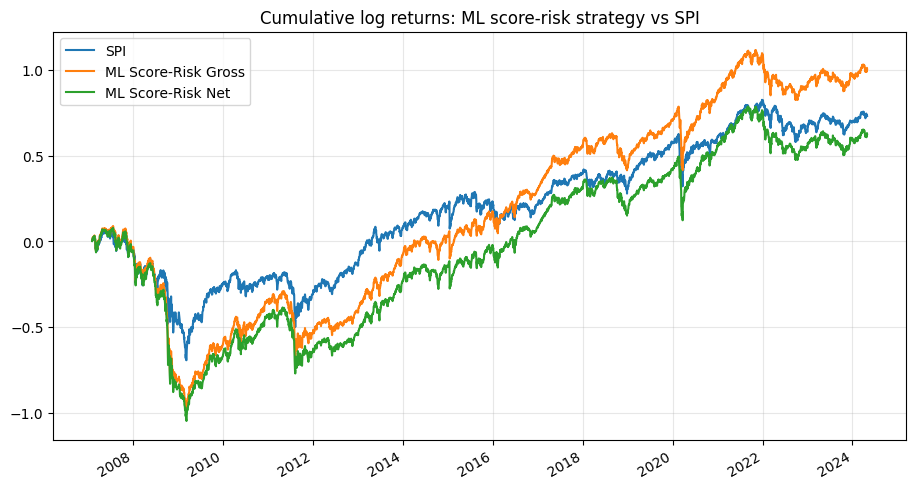

,SPI,ML Score-Risk Gross,ML Score-Risk Net
2024-04-24,-0.007765,-0.006866,-0.006906
2024-04-25,-0.009336,-0.009171,-0.009210
2024-04-26,0.008030,0.013054,0.013014
2024-04-29,-0.000049,0.011409,0.011291
2024-04-30,-0.004532,-0.006167,-0.006207


In [27]:
strategy_gross = bt_ml_sv.strategy.simulate(
    return_series=return_series,
    fc=0,
    vc=0,
)

strategy_net = strategy_gross.copy()

fixed_costs = 0.01
variable_cost_rate = 0.002

n_days = (strategy_net.index[1:] - strategy_net.index[:-1]).to_numpy().astype('timedelta64[D]').astype(int)
daily_fixed_costs = (1 + fixed_costs) ** (n_days / 252) - 1
strategy_net.iloc[1:] = strategy_net.iloc[1:] - daily_fixed_costs

variable_costs = turnover * variable_cost_rate
for date, cost in variable_costs.items():
    future_return_dates = strategy_net.index[strategy_net.index >= pd.to_datetime(date)]
    if len(future_return_dates) > 0:
        strategy_net.loc[future_return_dates[0]] = strategy_net.loc[future_return_dates[0]] - cost

sim = pd.concat({
    'SPI': data.bm_series,
    'ML Score-Risk Gross': strategy_gross,
    'ML Score-Risk Net': strategy_net,
}, axis=1).dropna()

np.log(1 + sim).cumsum().plot(
    title='Cumulative log returns: ML score-risk strategy vs SPI',
    figsize=(11, 6),
)
plt.grid(alpha=0.3)
plt.show()

sim.tail()

## Rolling returns and drawdowns

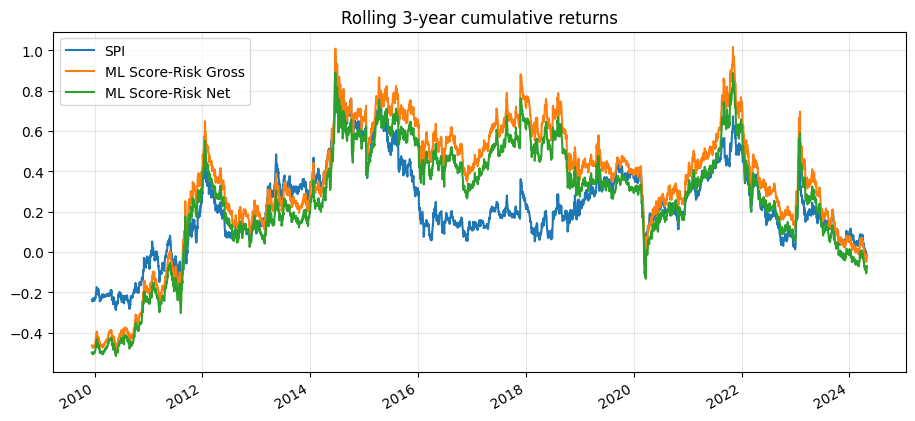

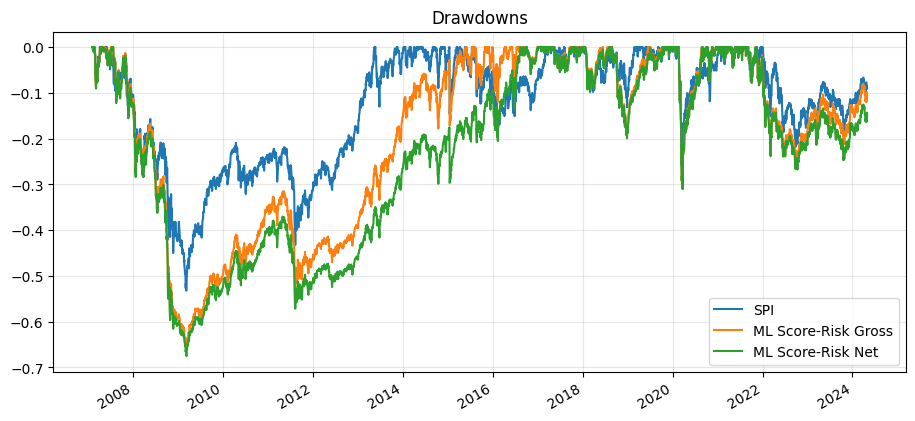

In [28]:
rolling_3y_returns = (1 + sim).rolling(252 * 3).apply(np.prod, raw=True) - 1
rolling_3y_returns.plot(
    title='Rolling 3-year cumulative returns',
    figsize=(11, 5),
)
plt.grid(alpha=0.3)
plt.show()

wealth = (1 + sim).cumprod()
drawdowns = wealth / wealth.cummax() - 1
drawdowns.plot(
    title='Drawdowns',
    figsize=(11, 5),
)
plt.grid(alpha=0.3)
plt.show()

## Performance statistics

In [29]:
def performance_stats(returns, benchmark_col='SPI', periods_per_year=252):
    stats = {}

    for col in returns.columns:
        r = returns[col].dropna()
        wealth = (1 + r).cumprod()
        drawdown = wealth / wealth.cummax() - 1

        stats[col] = {
            'Mean Daily Return': r.mean(),
            'Annual Return': (1 + r).prod() ** (periods_per_year / len(r)) - 1,
            'Annual Volatility': r.std() * np.sqrt(periods_per_year),
            'Sharpe Ratio': r.mean() / r.std() * np.sqrt(periods_per_year),
            'Cumulative Return': wealth.iloc[-1] - 1,
            'Max Drawdown': drawdown.min(),
        }

        if col != benchmark_col:
            active = (returns[col] - returns[benchmark_col]).dropna()
            stats[col]['Tracking Error'] = active.std() * np.sqrt(periods_per_year)
            stats[col]['Information Ratio'] = active.mean() / active.std() * np.sqrt(periods_per_year)
        else:
            stats[col]['Tracking Error'] = np.nan
            stats[col]['Information Ratio'] = np.nan

    return pd.DataFrame(stats).T

full_period_stats = performance_stats(sim)
full_period_stats

,Mean Daily Return,Annual Return,Annual Volatility,Sharpe Ratio,Cumulative Return,Max Drawdown,Tracking Error,Information Ratio
SPI,0.000213,0.041364,0.162443,0.330934,1.080523,-0.532487,NaN,NaN
ML Score-Risk Gross,0.000273,0.057282,0.161376,0.426229,1.736915,-0.662631,0.085700,0.175322
ML Score-Risk Net,0.000189,0.035247,0.161390,0.295686,0.870368,-0.675479,0.085789,-0.070371


## Subperiod statistics

In [30]:
split_date = sim.index.max() - pd.DateOffset(years=5)

early_period_stats = performance_stats(sim.loc[sim.index < split_date])
last_5y_stats = performance_stats(sim.loc[sim.index >= split_date])

subperiod_stats = pd.concat({
    'Full period': full_period_stats,
    'Before last 5 years': early_period_stats,
    'Last 5 years': last_5y_stats,
}, axis=0)

subperiod_stats

Mean Daily Return  Annual Return  \
Full period         SPI                           0.000213       0.041364   
                    ML Score-Risk Gross           0.000273       0.057282   
                    ML Score-Risk Net             0.000189       0.035247   
Before last 5 years SPI                           0.000205       0.038152   
                    ML Score-Risk Gross           0.000239       0.047952   
                    ML Score-Risk Net             0.000155       0.026004   
Last 5 years        SPI                           0.000233       0.049252   
                    ML Score-Risk Gross           0.000356       0.080426   
                    ML Score-Risk Net             0.000274       0.058179   

                                         Annual Volatility  Sharpe Ratio  \
Full period         SPI                           0.162443      0.330934   
                    ML Score-Risk Gross           0.161376      0.426229   
                    ML Score-Risk Net             0.161390      0.295686   
Before last 5 years SPI                           0.168765      0.306369   
                    ML Score-Risk Gross           0.163161      0.368985   
                    ML Score-Risk Net             0.163129      0.239260   
Last 5 years        SPI                           0.145912      0.402812   
                    ML Score-Risk Gross           0.156984      0.571662   
                    ML Score-Risk Net             0.157115      0.438862   

                                         Cumulative Return  Max Drawdown  \
Full period         SPI                           1.080523     -0.532487   
                    ML Score-Risk Gross           1.736915     -0.662631   
                    ML Score-Risk Net             0.870368     -0.675479   
Before last 5 years SPI                           0.616420     -0.532487   
                    ML Score-Risk Gross           0.823427     -0.662631   
                    ML Score-Risk Net             0.389927     -0.675479   
Last 5 years        SPI                           0.287118     -0.263289   
                    ML Score-Risk Gross           0.500973     -0.309748   
                    ML Score-Risk Net             0.345659     -0.310668   

                                         Tracking Error  Information Ratio  
Full period         SPI                             NaN                NaN  
                    ML Score-Risk Gross        0.085700           0.175322  
                    ML Score-Risk Net          0.085789          -0.070371  
Before last 5 years SPI                             NaN                NaN  
                    ML Score-Risk Gross        0.084929           0.100079  
                    ML Score-Risk Net          0.085031          -0.149055  
Last 5 years        SPI                             NaN                NaN  
                    ML Score-Risk Gross        0.087580           0.353581  
                    ML Score-Risk Net          0.087639           0.116123

## Calendar-year returns

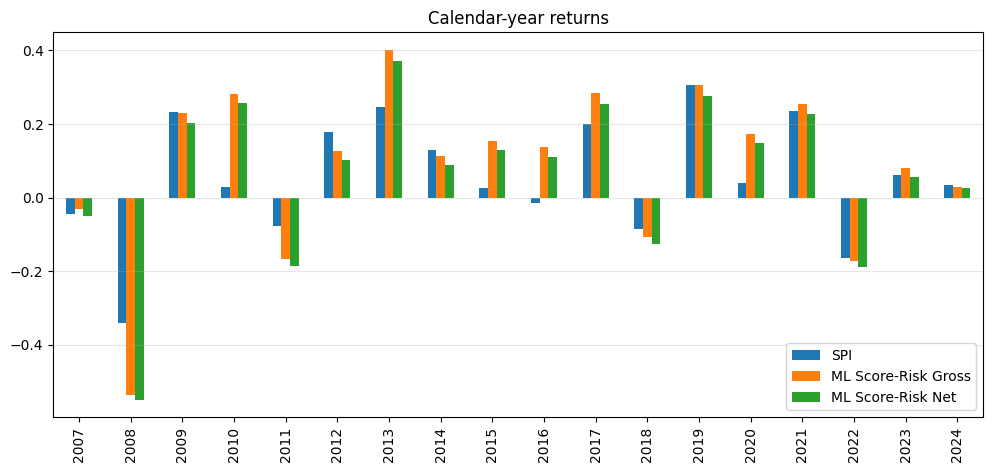

,SPI,ML Score-Risk Gross,ML Score-Risk Net
2007,-0.043683,-0.031090,-0.051270
2008,-0.340465,-0.537956,-0.549063
2009,0.231815,0.228351,0.202333
2010,0.029187,0.282191,0.255511
2011,-0.077211,-0.168039,-0.186065
2012,0.177224,0.125863,0.101408
2013,0.246002,0.402202,0.372091
2014,0.130012,0.112287,0.089063
2015,0.026752,0.154415,0.129509
2016,-0.014105,0.136177,0.110514


In [31]:
calendar_year_returns = sim.resample('YE').apply(lambda x: (1 + x).prod() - 1)
calendar_year_returns.index = calendar_year_returns.index.year

calendar_year_returns.plot(
    kind='bar',
    title='Calendar-year returns',
    figsize=(12, 5),
)
plt.grid(axis='y', alpha=0.3)
plt.show()

calendar_year_returns

## Active return analysis

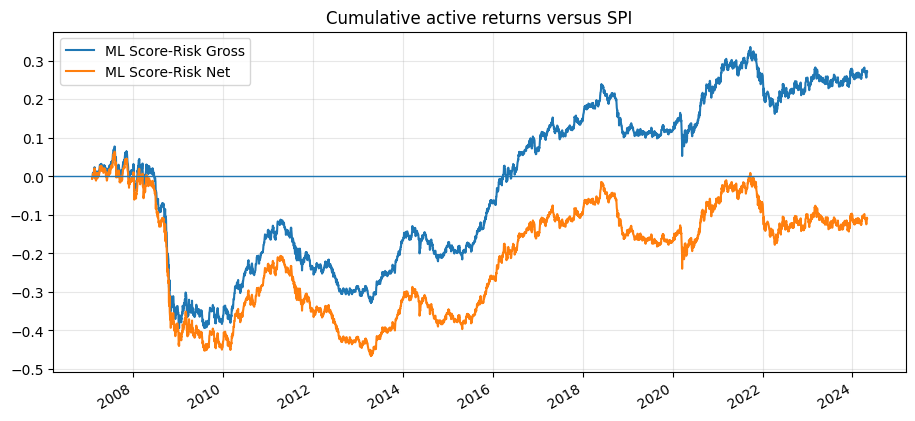

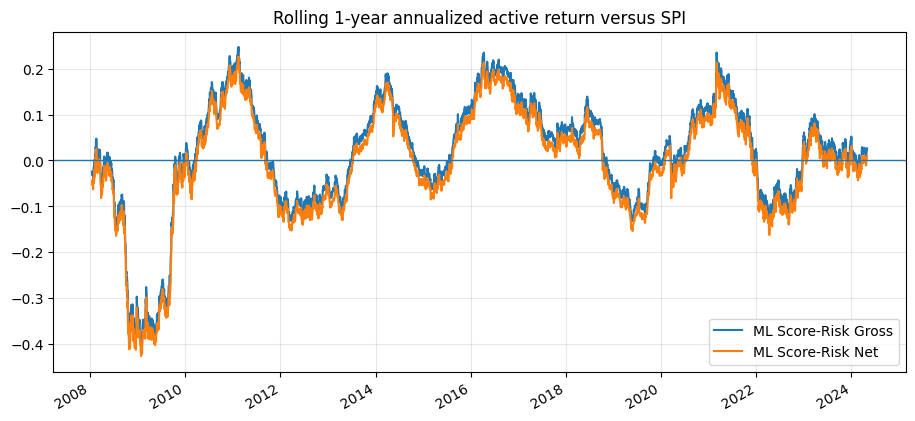

,ML Score-Risk Gross,ML Score-Risk Net
count,4555.000000,4555.000000
mean,0.000060,-0.000024
std,0.005399,0.005404
min,-0.054006,-0.054046
25%,-0.002652,-0.002752
50%,0.000000,-0.000039
75%,0.003017,0.002943
max,0.032072,0.031993


In [32]:
active_returns = sim[['ML Score-Risk Gross', 'ML Score-Risk Net']].sub(sim['SPI'], axis=0)

active_returns.cumsum().plot(
    title='Cumulative active returns versus SPI',
    figsize=(11, 5),
)
plt.axhline(0, linewidth=1)
plt.grid(alpha=0.3)
plt.show()

active_returns.rolling(252).mean().mul(252).plot(
    title='Rolling 1-year annualized active return versus SPI',
    figsize=(11, 5),
)
plt.axhline(0, linewidth=1)
plt.grid(alpha=0.3)
plt.show()

active_returns.describe()

## Report summary

The strategy uses the cross-section of Swiss equity characteristics to forecast next-quarter relative returns. The predictive model is intentionally simple: Ridge regression with rolling out-of-sample training. This makes the signal stable, reproducible, and less exposed to overfitting than a high-capacity model.

The selection stage combines three filters: liquidity-gap filtering, minimum-volume filtering, and a custom quality-risk filter. The optimization stage uses the course framework through `SelectionItemBuilder`, `OptimizationItemBuilder`, `bibfn_return_series`, `bibfn_scores`, `bibfn_budget_constraint`, and `bibfn_box_constraints`. Portfolio weights are determined by `ScoreVariance`, which maximizes the ML score while penalizing covariance risk.

The backtest is benchmarked against the SPI. The gross strategy return shows the investment result before trading frictions. The net strategy deducts annual fixed costs of 1% and transaction costs of 0.2% per unit of turnover at each rebalancing date. The tables and charts above report cumulative performance, rolling 3-year returns, drawdowns, turnover, full-period statistics, last-5-year statistics, calendar-year returns, and active return behavior versus SPI.